<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Epoch   1/100 | LR: 3.16e-04 | train loss 0.9897 acc 0.597 | val loss 0.7383 acc 0.681 *


[DenseNet-121] Epoch   2/100 | LR: 3.16e-04 | train loss 0.8752 acc 0.689 | val loss 0.5688 acc 0.797 *


[DenseNet-121] Epoch   3/100 | LR: 3.16e-04 | train loss 0.8259 acc 0.698 | val loss 0.6050 acc 0.772


[DenseNet-121] Epoch   4/100 | LR: 3.16e-04 | train loss 0.7918 acc 0.702 | val loss 0.5642 acc 0.781 *


[DenseNet-121] Epoch   5/100 | LR: 3.16e-04 | train loss 0.7747 acc 0.711 | val loss 0.6055 acc 0.756


...

[DenseNet-121] Epoch  39/100 | LR: 3.16e-05 | train loss 0.2018 acc 0.935 | val loss 0.4819 acc 0.825


[DenseNet-121] Epoch  40/100 | LR: 3.16e-06 | train loss 0.2224 acc 0.927 | val loss 0.4625 acc 0.841


[DenseNet-121] Epoch  41/100 | LR: 3.16e-06 | train loss 0.2043 acc 0.930 | val loss 0.4917 acc 0.838


[DenseNet-121] Epoch  42/100 | LR: 3.16e-06 | train loss 0.1639 acc 0.943 | val loss 0.4938 acc 0.825


[DenseNet-121] Epoch  43/100 | LR: 3.16e-06 | train loss 0.1973 acc 0.937 | val loss 0.5120 acc 0.819

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 43.

[DenseNet-121] Restored best checkpoint (val loss = 0.3903)


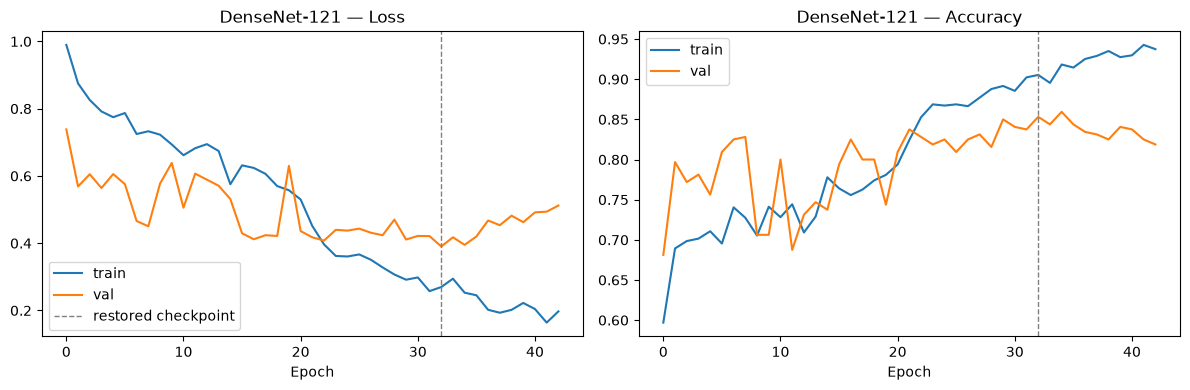

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.673


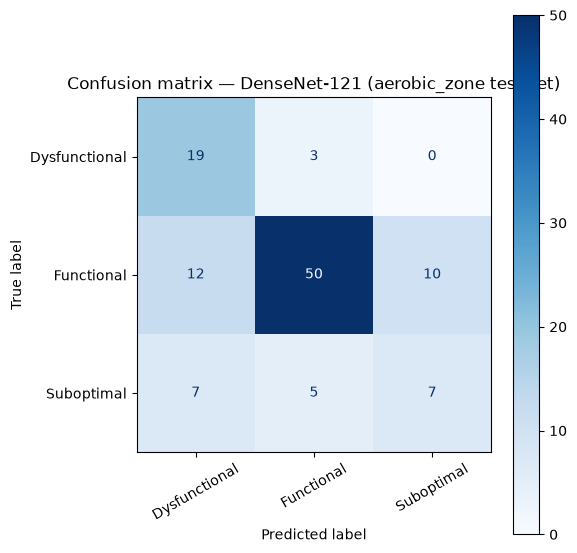

               precision    recall  f1-score   support

Dysfunctional      0.500     0.864     0.633        22
   Functional      0.862     0.694     0.769        72
   Suboptimal      0.412     0.368     0.389        19

     accuracy                          0.673       113
    macro avg      0.591     0.642     0.597       113
 weighted avg      0.716     0.673     0.679       113



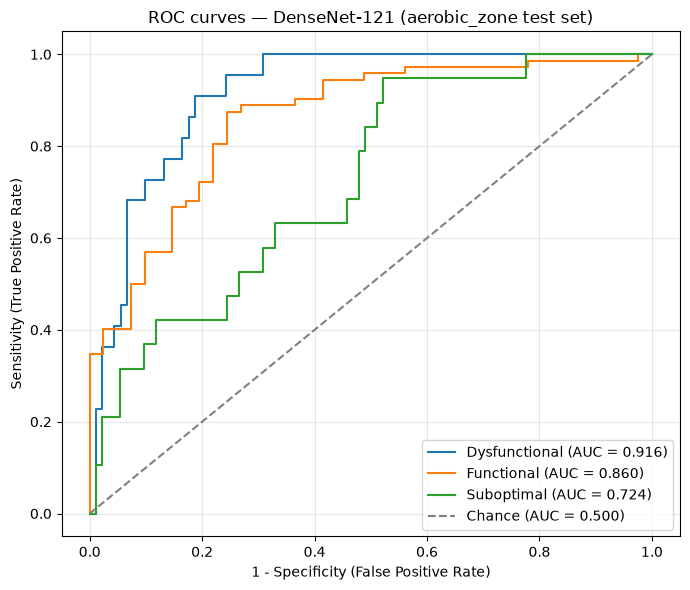

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.916
  Functional     : 0.860
  Suboptimal     : 0.724

Mean AUC (over 3/3 classes with test examples): 0.833


(np.float64(0.672566371681416),
 {'Dysfunctional': 0.9155844155844156,
  'Functional': 0.8597560975609756,
  'Suboptimal': 0.7239641657334827})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_densenet121_Atlantis.pkl


Saved model weights to ../models/aerobic_zone_densenet121_cnn.pt
